In [1]:
import helpers
import numpy as np
import os
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch
from sklearn.metrics import classification_report


In [2]:
filepath = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\image\CINE_4CH_014.nii.gz"
labelpath= r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\anno\CINE_4CH_014.nii.gz"

dt = helpers.nii_to_tensor(filepath)
print(type(dt))

print(dt.shape)

<class 'torch.Tensor'>
torch.Size([169, 155, 90])


In [3]:
# helpers.visualize_nii_file("4CH", data_path=filepath, label_path=labelpath, frame_delay=50)

In [4]:
# I will simply load the entire dataset into a data loader (for batch processing)
train_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\image"
mask_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\anno"


mriTraining_instance, mri_Testset_instance = helpers.Create_Dataset(train_dataset_path, mask_dataset_path)
Trainloader = DataLoader(mriTraining_instance, batch_size = 10, shuffle = True)
Testloader = DataLoader(mri_Testset_instance, batch_size = 10, shuffle = True)

All dataset is of length 105
With Masks of105
Splitting data to 0.7 for training and 0.3 for testing...
Training with 74:74
Testing with 31:31


### Playing with dummy scripts

In [5]:
# I will simply load the entire dataset into a data loader (for batch processing)
train_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\image"
mask_dataset_path = r"C:\Users\ayman.mohamed\Personal\Masters_Security\Deep_Learning\CINE_Cardiac_MRI_With_Deep_Learning\CMR-MULTI\CINE_MULTI\4CH_TR\anno"


all_images = helpers.get_all_np_images(train_dataset_path)
zscaler, clipped_images = helpers.train_scaler(all_images)

mri_dataset, test_mri_dataset = helpers.create_2d_dataset(train_dataset_path, mask_dataset_path, scaler=zscaler)


batch_size = 20
mri_dataloader = DataLoader(mri_dataset, batch_size=batch_size)
test_mri_dataloader = DataLoader(test_mri_dataset, batch_size=batch_size)

classes = list(helpers.load_labels(Problem_Type="CINE", Image_Type="4CH").keys())
print(len(classes))
print(classes)

100%|██████████| 105/105 [00:51<00:00,  2.04it/s]


finished clipping 105 images
finished flattening 105 images to 217025575 pixels
finished training the scaler
All dataset is of length torch.Size([8285, 1, 169, 155]) 
With Masks of torch.Size([8285, 1, 169, 155])
Splitting data to 0.7 for training and 0.3 for testing...
Training with 5800:5800
Testing with 2485:2485
6
[0, 1, 2, 3, 4, 5]


In [10]:
########################## I STOLE THIS CODE :D ############################
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       """
       Building blocks of convolutional neural network.

       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. In our problem, 10 (i.e digits from  0 to 9).
       """
       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

       self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

       self.conv3 = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=3, padding=1)

       # Fully connected layer
       
       #self.fc1 = nn.Linear(25536, num_classes) # IMAGE WIDTH X HEIGHT

       #self.conv4 = nn.Conv2d(16, num_classes, kernel_size=1)

   def forward(self, x):
        """
        Define the forward pass of the neural network.

        Parameters:
            x: Input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        orig_size = x.shape[2:]   # (H, W)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        #x = self.conv4(x)   # (N, C, H, W)
        x = F.interpolate(x, size=orig_size, mode='bilinear', align_corners=False)

        return x
   



device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels=1, num_classes=len(classes)).to(device)
print(model)



# Define the loss function
#criterion = nn.CrossEntropyLoss()
    

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        
        # Convert logits to probabilities over class dimension
        probs = torch.softmax(logits, dim=1)  # (N, C, H, W)
        
        # One-hot encode targets: (N, H, W) -> (N, C, H, W)
        targets_one_hot = torch.zeros_like(probs)  # (N, C, H, W)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1)  # fill class channels
        
        # Flatten spatial dims, keep class dim: (N, C, H*W)
        probs = probs.view(probs.shape[0], num_classes, -1)
        targets_one_hot = targets_one_hot.view(targets_one_hot.shape[0], num_classes, -1)
        
        # Compute Dice per class, then average
        intersection = (probs * targets_one_hot).sum(dim=2)  # (N, C)
        dice = (2. * intersection + self.smooth) / (
            probs.sum(dim=2) + targets_one_hot.sum(dim=2) + self.smooth
        )  # (N, C)
        
        dice = dice[:, 1:]   # ignore class 0
        return 1 - dice.mean()
    
# Define the loss function
class_weights = torch.tensor([0.1, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=torch.float).to(device)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)


def combined_loss(logits, targets):
    return ce_loss(logits, targets) + DiceLoss()(logits, targets)

criterion = combined_loss


# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)



num_epochs=50
for epoch in range(num_epochs):
 # Iterate over training batches
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    running_loss = 0.0
    total_samples = 0
    for batch_index, (data, targets) in enumerate(tqdm(mri_dataloader)):
        data = data.to(device)
        targets = targets.to(device)
        targets = targets.squeeze(1).long()
        scores = model(data)
        loss = criterion(scores, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # To compute the running loss
        batch_size = data.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        # print("Output stats:", scores.min().item(), scores.max().item())
        # print("Pred unique:", torch.unique(torch.argmax(scores, dim=1)))
        # print("GT unique:", torch.unique(targets))
        
    
    epoch_loss = running_loss / total_samples
    print(f"Epoch [{epoch + 1}] Loss: {epoch_loss:.4f}")



model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_mri_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        labels = labels.squeeze(1).long()

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.view(-1).cpu())
        all_targets.append(labels.view(-1).cpu())
        print(torch.unique(preds))

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print(classification_report(all_targets.numpy(), all_preds.numpy()))

CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
Epoch [1/50]


  0%|          | 0/290 [00:00<?, ?it/s]

100%|██████████| 290/290 [03:42<00:00,  1.30it/s]


Epoch [1] Loss: 2.4875
Epoch [2/50]


100%|██████████| 290/290 [03:53<00:00,  1.24it/s]


...

100%|██████████| 290/290 [03:18<00:00,  1.46it/s]


Epoch [50] Loss: 1.7867
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2,

c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.87      0.83      0.85  49703651
           1       0.54      0.06      0.11   4722806
           2       0.05      0.03      0.04   2918103
           3       0.27      0.02      0.04   2687392
           4       0.11      0.79      0.20   2183769
           5       0.00      0.00      0.00   2878854

    accuracy                           0.67  65094575
   macro avg       0.31      0.29      0.21  65094575
weighted avg       0.72      0.67      0.67  65094575



c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_mri_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        labels = labels.squeeze(1).long()

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.view(-1).cpu())
        all_targets.append(labels.view(-1).cpu())
        #print(torch.unique(preds))

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print(classification_report(all_targets.numpy(), all_preds.numpy()))

c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.87      0.83      0.85  49703651
           1       0.54      0.06      0.11   4722806
           2       0.05      0.03      0.04   2918103
           3       0.27      0.02      0.04   2687392
           4       0.11      0.79      0.20   2183769
           5       0.00      0.00      0.00   2878854

    accuracy                           0.67  65094575
   macro avg       0.31      0.29      0.21  65094575
weighted avg       0.72      0.67      0.67  65094575



c:\Users\ayman.mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


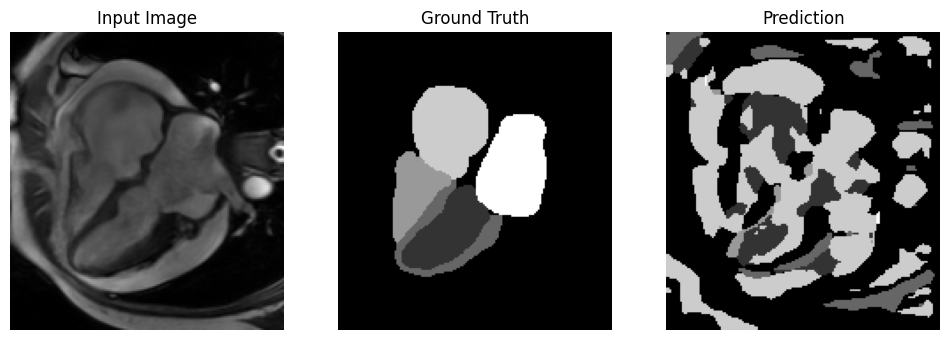

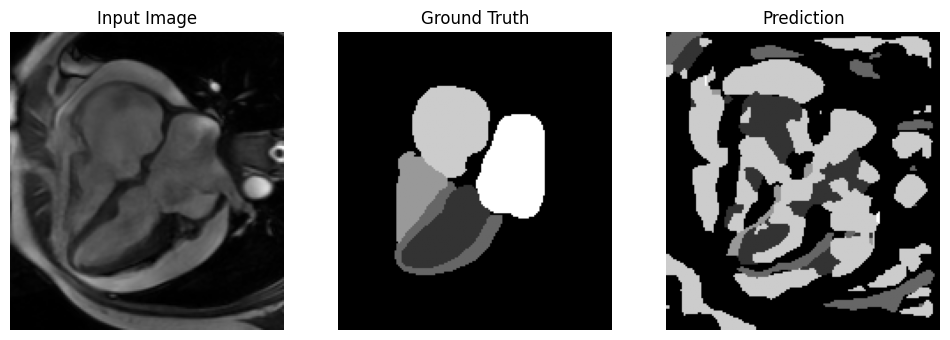

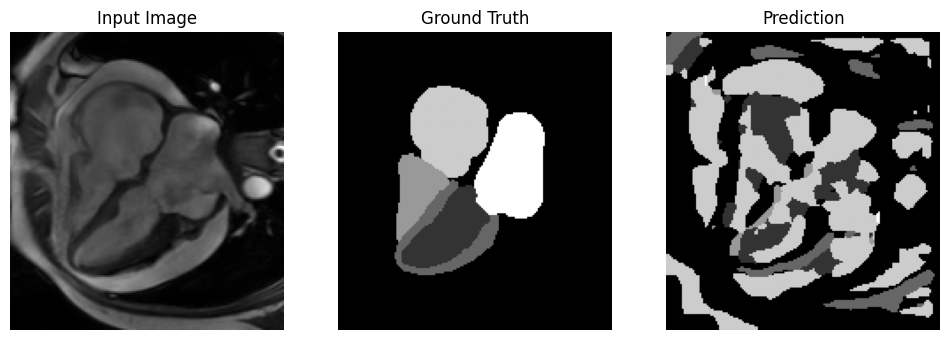

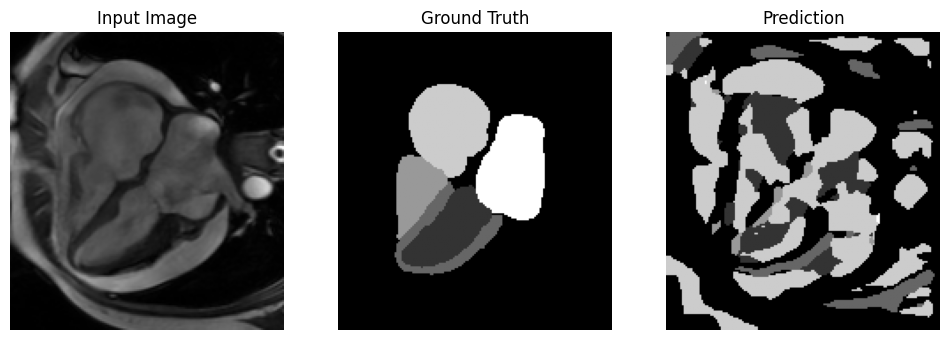

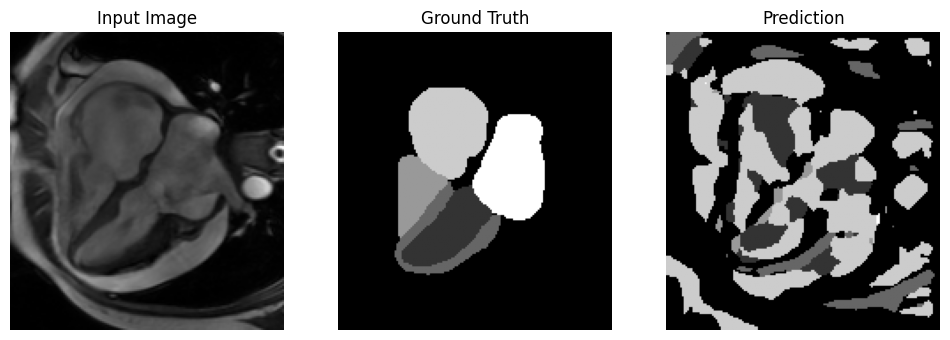

In [ ]:
images, masks = next(iter(test_mri_dataloader))

images = images.to(device)
masks = masks.to(device)

masks = masks.squeeze(1).long()

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)    

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()


import matplotlib.pyplot as plt

def visualize_sample(img, mask, pred, idx):
    plt.figure(figsize=(12,4))

    # Input image
    plt.subplot(1,3,1)
    plt.title("Input Image")
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')

    # Ground truth
    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    # Prediction
    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred, cmap='gray')
    plt.axis('off')

    plt.show()



for i in range(5):  # change number as you like
    visualize_sample(images[i], masks[i], preds[i], i)